In [100]:
# %pip install pandas numpy matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Part 1: Original Score vs Modified

In [101]:
games = pd.read_csv('games.csv')
games2 = pd.read_csv('games2.csv')

In [102]:
games.head()

,gameId,season,week,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr,homeFinalScore,visitorFinalScore
0,2022090800,2022,1,09/08/2022,20:20:00,LA,BUF,10,31
1,2022091100,2022,1,09/11/2022,13:00:00,ATL,NO,26,27
2,2022091101,2022,1,09/11/2022,13:00:00,CAR,CLE,24,26
3,2022091102,2022,1,09/11/2022,13:00:00,CHI,SF,19,10
4,2022091103,2022,1,09/11/2022,13:00:00,CIN,PIT,20,23


In [103]:
games2.head()

,gameId,season,week,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr,homeFinalScore,visitorFinalScore
0,2022090800,2022,1,9/8/2022,20:20:00,LA,BUF,10,31
1,2022091100,2022,1,9/11/2022,13:00:00,ATL,NO,26,27
2,2022091101,2022,1,9/11/2022,13:00:00,CAR,CLE,24,26
3,2022091102,2022,1,9/11/2022,13:00:00,CHI,SF,19,10
4,2022091103,2022,1,9/11/2022,13:00:00,CIN,PIT,20,23


In [104]:
games[games['week']==6]

,gameId,season,week,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr,homeFinalScore,visitorFinalScore
80,2022101300,2022,6,10/13/2022,20:15:00,CHI,WAS,7,12
81,2022101600,2022,6,10/16/2022,13:00:00,ATL,SF,28,14
82,2022101601,2022,6,10/16/2022,13:00:00,CLE,NE,15,38
83,2022101602,2022,6,10/16/2022,13:00:00,GB,NYJ,10,27
84,2022101603,2022,6,10/16/2022,13:00:00,IND,JAX,34,27
85,2022101604,2022,6,10/16/2022,13:00:00,MIA,MIN,16,24
86,2022101605,2022,6,10/16/2022,13:00:00,NO,CIN,26,30
87,2022101606,2022,6,10/16/2022,13:00:00,NYG,BAL,24,20
88,2022101607,2022,6,10/16/2022,13:00:00,PIT,TB,20,18
89,2022101608,2022,6,10/16/2022,16:05:00,LA,CAR,24,10


In [105]:
games[(games['week'] == 6) & (games['homeTeamAbbr'] == 'LAC') & (games['visitorTeamAbbr'] == 'DEN')]

,gameId,season,week,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr,homeFinalScore,visitorFinalScore
93,2022101700,2022,6,10/17/2022,20:15:00,LAC,DEN,19,16


In [106]:
games2[(games2['week'] == 6) & (games2['homeTeamAbbr'] == 'LAC') & (games2['visitorTeamAbbr'] == 'DEN')]

,gameId,season,week,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr,homeFinalScore,visitorFinalScore
93,2022101700,2022,6,10/17/2022,20:15:00,LAC,DEN,21,17


In [107]:
orig = games[(games['week'] == 6) & (games['homeTeamAbbr'] == 'LAC') & (games['visitorTeamAbbr'] == 'DEN')].iloc[0]
modified = games2[(games2['week'] == 6) & (games2['homeTeamAbbr'] == 'LAC') & (games2['visitorTeamAbbr'] == 'DEN')].iloc[0]

### Original Score vs Modified Score

In [108]:
print("Original Score:")
print (f"{orig['homeTeamAbbr']}: {orig['homeFinalScore']}")
print(f"{orig['visitorTeamAbbr']}: {orig['visitorFinalScore']}")


print("Modified Score:")
print (f"{modified['homeTeamAbbr']}: {modified['homeFinalScore']}")
print(f"{modified['visitorTeamAbbr']}: {modified['visitorFinalScore']}")


Original Score:
LAC: 19
DEN: 16
Modified Score:
LAC: 21
DEN: 17


## Part 2: Play Animation

In [109]:
# finding the game
games[games['gameId'] == 2022100210]

,gameId,season,week,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr,homeFinalScore,visitorFinalScore
58,2022100210,2022,4,10/02/2022,13:00:00,PIT,NYJ,20,24


In [110]:
plays = pd.read_csv('plays.csv')
plays.head()

,gameId,playId,ballCarrierId,ballCarrierDisplayName,playDescription,quarter,down,yardsToGo,possessionTeam,defensiveTeam,...,preSnapHomeTeamWinProbability,preSnapVisitorTeamWinProbability,homeTeamWinProbabilityAdded,visitorTeamWinProbilityAdded,expectedPoints,expectedPointsAdded,foulName1,foulName2,foulNFLId1,foulNFLId2
0,2022100908,3537,48723,Parker Hesse,(7:52) (Shotgun) M.Mariota pass short middle t...,4,1,10,ATL,TB,...,0.976785,0.023215,-0.006110,0.006110,2.360609,0.981955,NaN,NaN,NaN,NaN
1,2022091103,3126,52457,Chase Claypool,(7:38) (Shotgun) C.Claypool right end to PIT 3...,4,1,10,PIT,CIN,...,0.160485,0.839515,-0.010865,0.010865,1.733344,-0.263424,NaN,NaN,NaN,NaN
2,2022091111,1148,42547,Darren Waller,(8:57) D.Carr pass short middle to D.Waller to...,2,2,5,LV,LAC,...,0.756661,0.243339,-0.037409,0.037409,1.312855,1.133666,NaN,NaN,NaN,NaN
3,2022100212,2007,46461,Mike Boone,(13:12) M.Boone left tackle to DEN 44 for 7 ya...,3,2,10,DEN,LV,...,0.620552,0.379448,-0.002451,0.002451,1.641006,-0.043580,NaN,NaN,NaN,NaN
4,2022091900,1372,47857,Devin Singletary,(8:33) D.Singletary right guard to TEN 32 for ...,2,1,10,BUF,TEN,...,0.836290,0.163710,0.001053,-0.001053,3.686428,-0.167903,NaN,NaN,NaN,NaN


In [111]:
plays[plays['playId'] == 2735]

,gameId,playId,ballCarrierId,ballCarrierDisplayName,playDescription,quarter,down,yardsToGo,possessionTeam,defensiveTeam,...,preSnapHomeTeamWinProbability,preSnapVisitorTeamWinProbability,homeTeamWinProbabilityAdded,visitorTeamWinProbilityAdded,expectedPoints,expectedPointsAdded,foulName1,foulName2,foulNFLId1,foulNFLId2
4278,2022100210,2735,54501,Breece Hall,(6:00) Br.Hall up the middle to PIT 47 for 5 y...,3,1,10,NYJ,PIT,...,0.571213,0.428787,-6.410000e-07,6.410000e-07,2.874722,-0.008613,NaN,NaN,NaN,NaN


In [112]:
plays.info()

<class 'pandas.DataFrame'>
RangeIndex: 12486 entries, 0 to 12485
Data columns (total 35 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   gameId                            12486 non-null  int64  
 1   playId                            12486 non-null  int64  
 2   ballCarrierId                     12486 non-null  int64  
 3   ballCarrierDisplayName            12486 non-null  str    
 4   playDescription                   12486 non-null  str    
 5   quarter                           12486 non-null  int64  
 6   down                              12486 non-null  int64  
 7   yardsToGo                         12486 non-null  int64  
 8   possessionTeam                    12486 non-null  str    
 9   defensiveTeam                     12486 non-null  str    
 10  yardlineSide                      12319 non-null  str    
 11  yardlineNumber                    12486 non-null  int64  
 12  gameClock      

In [113]:
# setting tracking data for week of the game
DATA = "/projects/class/spoa4001_u01/SportsTrackingTransformer/data/BigDataBowl_2024"
week = week = games.loc[games['gameId'] == 2022100210, 'week'].values[0]
print("Week:", week)

Week: 4


In [114]:
# setting tracking data for week of the game
tracking = pd.read_csv(f"{DATA}/tracking_week_{week}.csv")

In [115]:
tracking.head()

,gameId,playId,nflId,displayName,frameId,time,jerseyNumber,club,playDirection,x,y,s,a,dis,o,dir,event
0,2022092900,57,42654.0,La'el Collins,1,2022-09-29 20:16:00.099999,71.0,CIN,left,86.21,30.88,0.00,0.00,0.00,262.60,246.29,NaN
1,2022092900,57,42654.0,La'el Collins,2,2022-09-29 20:16:00.200000,71.0,CIN,left,86.21,30.88,0.00,0.00,0.00,263.32,234.76,NaN
2,2022092900,57,42654.0,La'el Collins,3,2022-09-29 20:16:00.299999,71.0,CIN,left,86.21,30.87,0.01,0.23,0.01,263.32,173.85,NaN
3,2022092900,57,42654.0,La'el Collins,4,2022-09-29 20:16:00.400000,71.0,CIN,left,86.21,30.86,0.07,0.69,0.01,263.32,191.83,NaN
4,2022092900,57,42654.0,La'el Collins,5,2022-09-29 20:16:00.500000,71.0,CIN,left,86.21,30.85,0.19,1.01,0.02,263.32,192.85,NaN


In [116]:
data = tracking[(tracking['gameId'] == 2022100210) & (tracking['playId'] == 2735)]
print(data)

             gameId  playId    nflId   displayName  frameId  \
1026099  2022100210    2735  35449.0  Tyson Alualu        1   
1026100  2022100210    2735  35449.0  Tyson Alualu        2   
1026101  2022100210    2735  35449.0  Tyson Alualu        3   
1026102  2022100210    2735  35449.0  Tyson Alualu        4   
1026103  2022100210    2735  35449.0  Tyson Alualu        5   
...             ...     ...      ...           ...      ...   
1027037  2022100210    2735      NaN      football       37   
1027038  2022100210    2735      NaN      football       38   
1027039  2022100210    2735      NaN      football       39   
1027040  2022100210    2735      NaN      football       40   
1027041  2022100210    2735      NaN      football       41   

                               time  jerseyNumber      club playDirection  \
1026099  2022-10-02 15:14:55.299999          94.0       PIT         right   
1026100  2022-10-02 15:14:55.400000          94.0       PIT         right   
1026101  202

In [117]:
# install nfl_tracks package
# %pip install nfl_tracks

In [118]:
from nfl import visuals

# DATA = "/projects/class/spoa4001_u01/SportsTrackingTransformer/data/BigDataBowl_2024"
# tracking = tracking_data = pd.read_csv(f"{DATA}/tracking_week_{week}.csv")
context_data = pd.read_csv(f"{DATA}/plays.csv")
# data = tracking[(tracking['gameId'] == 2022100210) & (tracking['playId'] == 2735)]

gameId = 2022100210
playId = 2735

#expects data to have game_id, play_id, etc, instead of CamelCase, we need to rename the columns to match
#play = visuals.Play(data, gameID, playID, context_data)

In [119]:
print(data.columns.tolist())
print(context_data.columns.tolist())

['gameId', 'playId', 'nflId', 'displayName', 'frameId', 'time', 'jerseyNumber', 'club', 'playDirection', 'x', 'y', 's', 'a', 'dis', 'o', 'dir', 'event']
['gameId', 'playId', 'ballCarrierId', 'ballCarrierDisplayName', 'playDescription', 'quarter', 'down', 'yardsToGo', 'possessionTeam', 'defensiveTeam', 'yardlineSide', 'yardlineNumber', 'gameClock', 'preSnapHomeScore', 'preSnapVisitorScore', 'passResult', 'passLength', 'penaltyYards', 'prePenaltyPlayResult', 'playResult', 'playNullifiedByPenalty', 'absoluteYardlineNumber', 'offenseFormation', 'defendersInTheBox', 'passProbability', 'preSnapHomeTeamWinProbability', 'preSnapVisitorTeamWinProbability', 'homeTeamWinProbabilityAdded', 'visitorTeamWinProbilityAdded', 'expectedPoints', 'expectedPointsAdded', 'foulName1', 'foulName2', 'foulNFLId1', 'foulNFLId2']


In [120]:
data = data.rename(columns={
    'gameId': 'game_id', 'playId': 'play_id', 'nflId': 'nfl_id',
    'frameId': 'frame_id', 'playDirection': 'play_direction'
})

In [121]:
# retrying with renamed columns
play = visuals.Play(data, gameId, playId, context_data)

In [122]:
context_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12486 entries, 0 to 12485
Data columns (total 35 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   gameId                            12486 non-null  int64  
 1   playId                            12486 non-null  int64  
 2   ballCarrierId                     12486 non-null  int64  
 3   ballCarrierDisplayName            12486 non-null  str    
 4   playDescription                   12486 non-null  str    
 5   quarter                           12486 non-null  int64  
 6   down                              12486 non-null  int64  
 7   yardsToGo                         12486 non-null  int64  
 8   possessionTeam                    12486 non-null  str    
 9   defensiveTeam                     12486 non-null  str    
 10  yardlineSide                      12319 non-null  str    
 11  yardlineNumber                    12486 non-null  int64  
 12  gameClock      

In [123]:
# package expects a player_side column with values 'Offense' or 'Defense', but we have possessionTeam and defensiveTeam columns instead. We use these to create the player_side column.
info = context_data[(context_data['gameId'] == gameId) & (context_data['playId'] == playId)].iloc[0]
offense = info['possessionTeam']
defense = info['defensiveTeam']
print(offense, defense)

NYJ PIT


In [124]:
# creating player_side column
data = data.copy()
data['player_side'] = data['club'].map({offense: 'Offense', defense: 'Defense'}).fillna('Football')
print(data['player_side'].value_counts())

player_side
Defense     451
Offense     451
Football     41
Name: count, dtype: int64


In [125]:
play = visuals.Play(data, gameId, playId, context_data)

In [126]:
# package wants ball_land_x and ball_land_y columns (based on 2026 dataset). We don't have taht but we can build these from tracking data.

ball = data[data['club'] == 'football']

# Prefer the frame where the pass arrived; otherwise use the ball's last position
landed = ball[ball['event'].isin(['pass_arrived', 'pass_outcome_caught', 'pass_outcome_incomplete'])]
land_row = landed.iloc[0] if len(landed) > 0 else ball.iloc[-1]

print("Ball landed at:", land_row['x'], land_row['y'], "| event:", land_row['event'])

Ball landed at: 62.7700004577637 32.689998626709 | event: nan


In [127]:
#creating columns for ball landing position
data['ball_land_x'] = land_row['x']
data['ball_land_y'] = land_row['y']

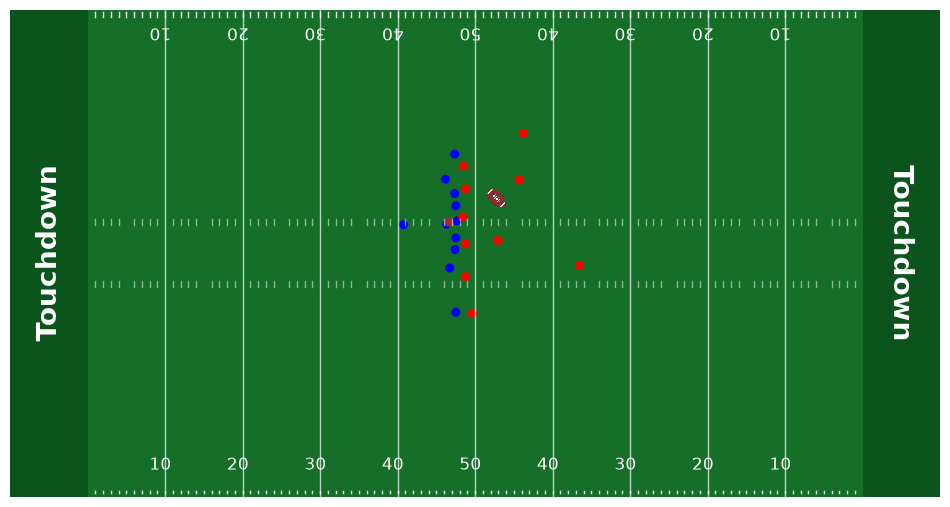

In [128]:
# Plots frame 10 of the play on a standard field
play = visuals.Play(data, gameId, playId, context_data)
fig, ax = play.plot_snap(frameId=10, club_colors={'Football': 'brown', 'Offense': 'blue', 'Defense': 'red'})
plt.show()

In [129]:
# Generates a standard animation of the play
# Use kaggle=True to display it in a notebook
standard_animation = play.animate(kaggle=True, club_colors={'Football': 'brown', 'Offense': 'white', 'Defense': 'gold'}, speed = 80)
standard_animation

In [130]:
help(play.animate)

Help on method animate in module nfl.visuals:

animate(save: bool = False, filename: str = None, relay: bool = False, highlight_player_id: int = None, kaggle=True, **kwargs) method of nfl.visuals.Play instance



In [131]:
# Saving animation as gif
play.animate(save = True, filename = "play_2735.gif", kaggle=True, club_colors={'Football': 'brown', 'Offense': 'white', 'Defense': 'gold'}, speed = 80)

Animation saved to play_2735.gif


Sources: 

nfl tracks package: https://github.com/shammeer-s/nfl-tracks 

Used Claude to help with troubleshooting.